Notebook to create visualizations/plots for the benchmark data obtained via `eval.py`.

## Imports and Config

In [2]:
import pandas as pd
import seaborn as sns   
import matplotlib.pyplot as plt

INPUT_DATA = "../data/benchmark_results.json"

## Plot the best result (F1) of each model for 'all' 

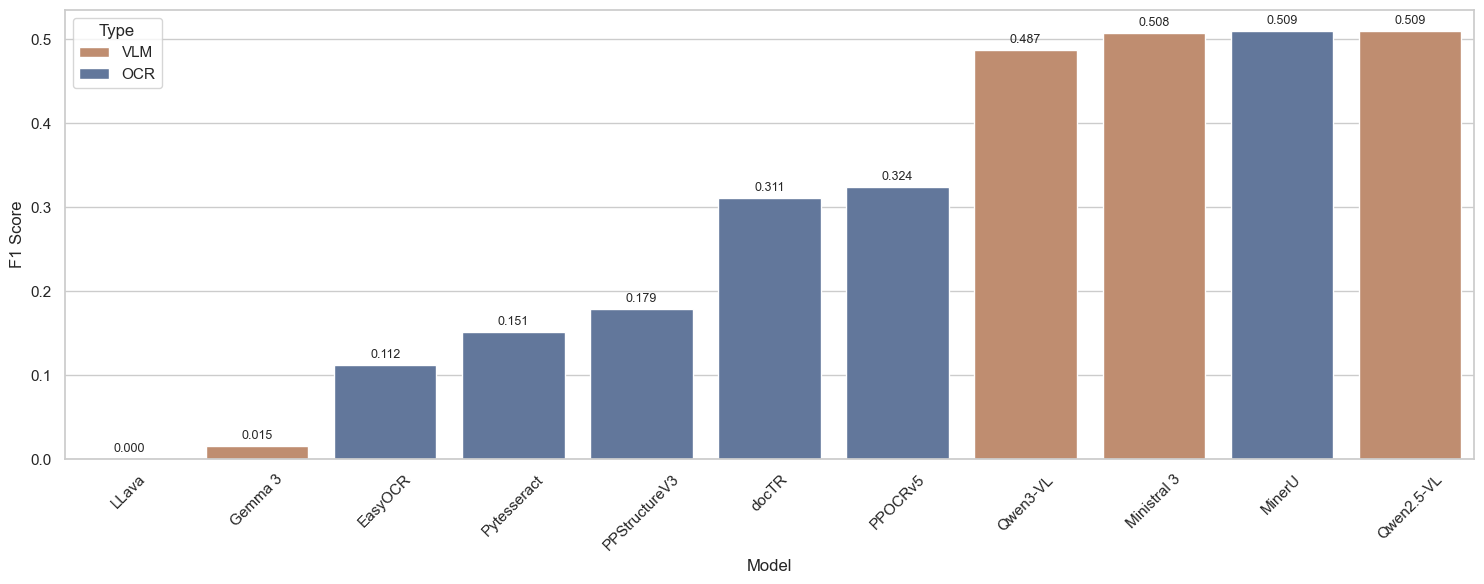

In [ ]:
df = pd.read_json(INPUT_DATA)
# print(df.to_latex(index=False, columns=["Eval Config", "OCR Engine", "Model", "Precision", "Recall", "F1"]))
df = df.loc[df['Eval Config'] == 'all']
# only get the best F1 score for each OCR Model + all VLMs
vlms = df[df['OCR Engine'] == 'N/A'].copy()
best_per_ocr_engine = (
    df[df['OCR Engine'] != 'N/A']
    .loc[df[df['OCR Engine'] != 'N/A']
    .groupby('OCR Engine')['F1'].idxmax()]
)
# concat and sort by F1
result = pd.concat([vlms, best_per_ocr_engine]).reset_index(drop=True)
result = result.sort_values('F1', ascending=True)
# reduce to values needed
plot_data = {
    'Model': [row['OCR Engine'] if row['OCR Engine'] != "N/A" else row['Model'] for _, row in result.iterrows()],
    'LLM': [row['Model'] if 'Qwen3:' in row['Model'] else 'N/A' for _, row in result.iterrows()],
    'Type': ['OCR' if 'Qwen3:' in row['Model'] else 'VLM' for _, row in result.iterrows()],
    'Score': [row['F1'] for _, row in result.iterrows()]
}
plot_df = pd.DataFrame(plot_data)
# print(plot_df.to_latex())
# add lil bars that show the different LLMs vor OCR models
sns.set_theme(style='whitegrid')
f, ax = plt.subplots(figsize=(15, 6))
sns.barplot(x="Model", y="Score", hue="Type", 
            palette={"VLM": "#CC8963", "OCR": "#5975A4"}, data=plot_df)

# Add values on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3, fontsize=9)

ax.set_xlabel("Model")
ax.set_ylabel("F1 Score")
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## Plot F1 Scores for each LLM size for each OCR model

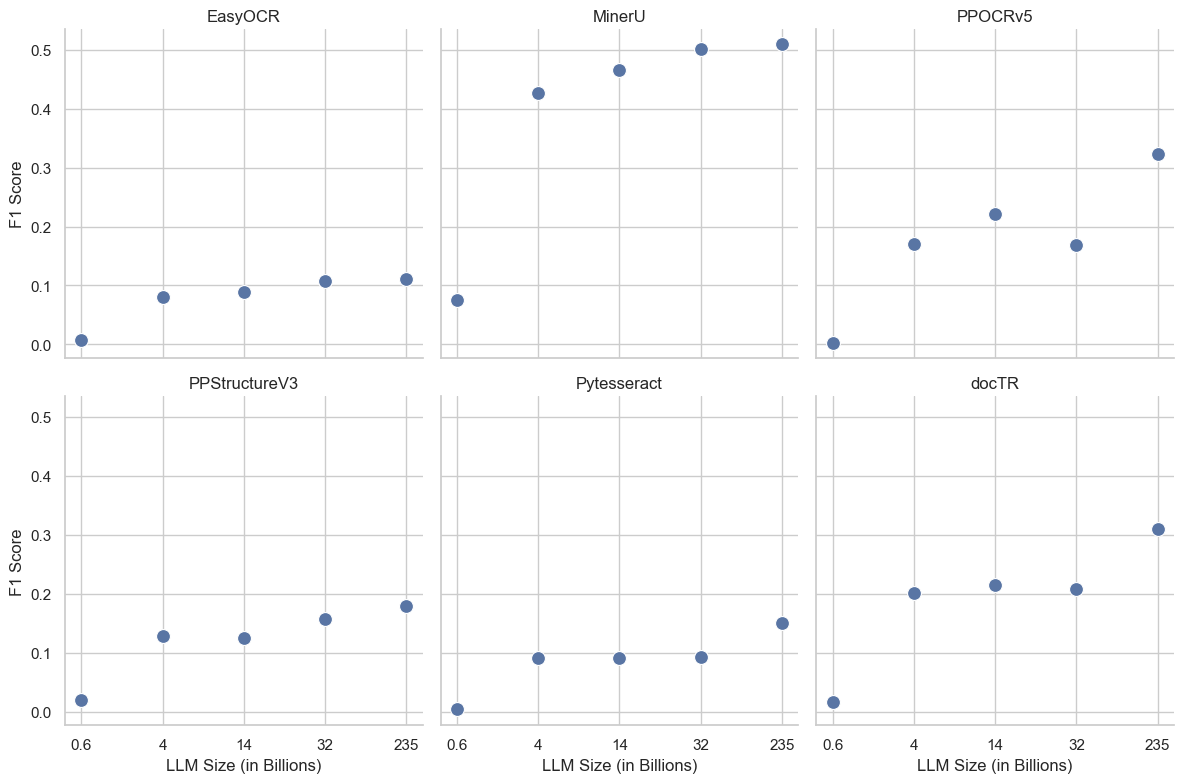

In [15]:
df = pd.read_json(INPUT_DATA)
df = df.loc[df['Eval Config'] == 'all'].copy()

# get LLM sizes
def extract_size(model):
    if "Qwen3:" in model:
        return float(model.split(":")[1].replace("b", ""))
    return None
df["LLM_size"] = df["Model"].apply(extract_size)

# get OCRs and sort by LLM size
df_ocr = df[df["OCR Engine"] != "N/A"].copy()
df_ocr = df_ocr.sort_values(["OCR Engine", "LLM_size"])

# map actual sizes to evenly spaced categorical positions
unique_sizes = sorted(df_ocr["LLM_size"].dropna().unique())
size_mapping = {size: i for i, size in enumerate(unique_sizes)}
df_ocr["LLM_pos"] = df_ocr["LLM_size"].map(size_mapping)

sns.set_theme(style="whitegrid")
g = sns.FacetGrid(
    df_ocr,
    col="OCR Engine",
    col_wrap=3,
    sharey=True,
    height=4
)
g.map_dataframe(
    sns.scatterplot,
    x="LLM_pos",
    y="F1",
    s=100,
    color="#5975A4"
)
g.set_titles(col_template="{col_name}")

for ax in g.axes.flat:
    ax.set_xticks(range(len(unique_sizes)))
    ax.set_xticklabels([str(int(s) if s.is_integer() else s) for s in unique_sizes])
    ax.set_xlabel("LLM Size (in Billions)")
g.set_ylabels("F1 Score")

plt.tight_layout()
plt.savefig("parameters.svg")
plt.show()


## Plot the difference between the "all" eval mode and the others

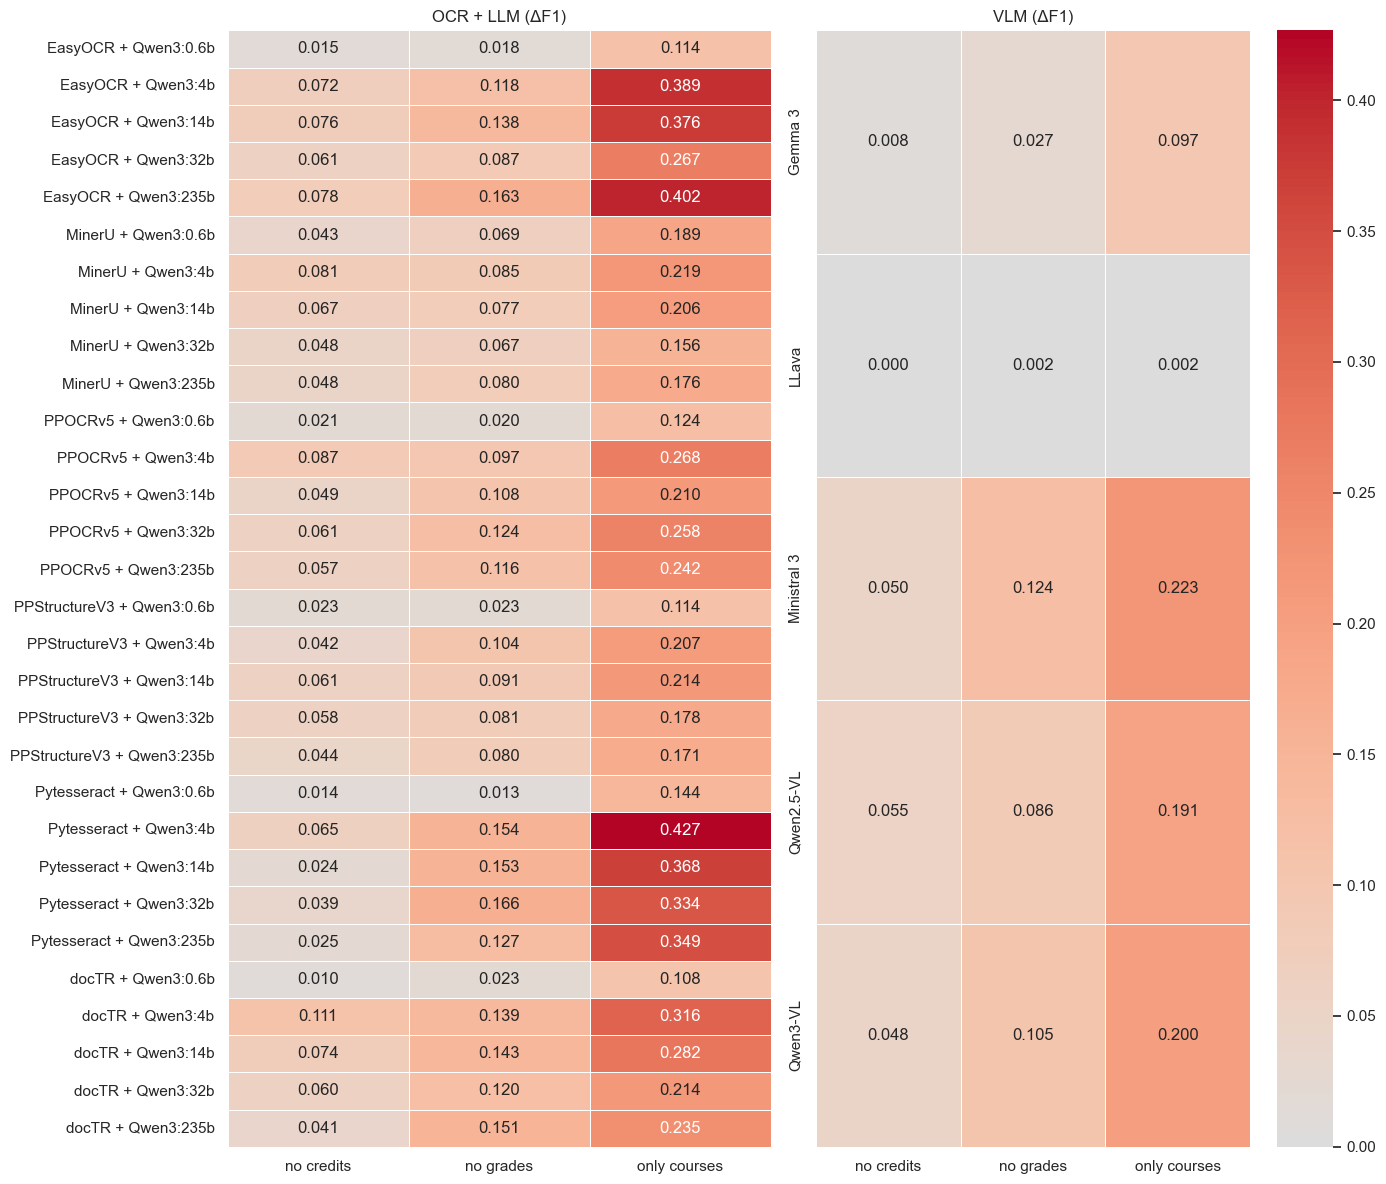

In [ ]:
df = pd.read_json(INPUT_DATA).copy()

df["System"] = df.apply(
    lambda row: f"{row['OCR Engine']} + {row['Model']}"
    if row["OCR Engine"] != "N/A"
    else row["Model"],
    axis=1
)

df["Type"] = df["OCR Engine"].apply(
    lambda x: "OCR" if x != "N/A" else "VLM"
)

pivot = df.pivot_table(
    index=["System", "Type"],
    columns="Eval Config",
    values="F1"
)

pivot.columns = pivot.columns.str.replace("_", " ", regex=False)

# ΔF1(config)=F1(config)−F1(all)
delta = pivot.subtract(pivot["all"], axis=0)
delta = delta.drop(columns=["all"])
delta_ocr = delta.xs("OCR", level="Type")
delta_vlm = delta.xs("VLM", level="Type")

delta_ocr = delta_ocr.iloc[
    sorted(
        range(len(delta_ocr)),
        key=lambda i: (
            delta_ocr.index[i].split(" + ")[0],
            float(delta_ocr.index[i].split(":")[-1].replace("b", ""))
        )
    )
]
sns.set_theme(style="white")

vmin = delta.min().min()
vmax = delta.max().max()

fig, axes = plt.subplots(
    ncols=2,
    figsize=(14, 12),
    sharey=False
)

# OCR heatmap
sns.heatmap(
    delta_ocr,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    vmin=vmin,
    vmax=vmax,
    ax=axes[0],
    cbar=False
)

axes[0].set_title("OCR + LLM (ΔF1)")
axes[0].set_xlabel("")
axes[0].set_ylabel("")

# VLM heatmap
sns.heatmap(
    delta_vlm,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    vmin=vmin,
    vmax=vmax,
    ax=axes[1],
    cbar=True
)

axes[1].set_title("VLM (ΔF1)")
axes[1].set_xlabel("")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

# negative numbers = got worse; positive numbers = got better